# 01 — Eksplorasi Data

Memvalidasi dan mengkalibrasi parameter `src/config.py` terhadap dataset nyata sebelum menulis chunker dan indexer.

Setiap sesi menghasilkan satu temuan konkret yang menjustifikasi sebuah pilihan konfigurasi — berguna baik untuk implementasi maupun sebagai bukti dalam presentasi.

| Sesi | Pertanyaan | Mempengaruhi |
|---|---|---|
| 1 | Jumlah baris nyata, NaN, ID duplikat | Sanity check |
| 2 | Distribusi kategori | UX filter sidebar, cek keseimbangan |
| 3 | Distribusi panjang `Resume_str` | `CHUNK_SIZE_FALLBACK` |
| 4 | Apakah konten `Resume_html` bocor ke `Resume_str`? | Perlu langkah cleaning? |
| 5 | % resume dengan header section terdeteksi | Chunking hybrid vs murni fixed-size |
| 6 | Varian pola header | Set regex untuk chunker |
| 7 | Estimasi biaya token & embedding | Validasi anggaran |
| 8 | Inspeksi visual sampel resume | Konsistensi format |

---

## Persiapan

In [15]:
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../dataset/resume/Resume.csv')
assert DATA_PATH.exists(), f'CSV not found at {DATA_PATH.resolve()}'

df = pd.read_csv(DATA_PATH)
print(f'shape: {df.shape}')
df.head()

shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Sesi 1 — Statistik sanity

**Pertanyaan:** berapa jumlah baris, kolom apa saja, ada NaN, ada ID duplikat?

**Prediksi sebelum menjalankan cell berikut:** header strip aplikasi mengklaim '2403 CV terindeks'. Apa yang Anda harapkan untuk `df.isna().sum()`?

In [16]:
print('Total rows  :', len(df))
print('Columns     :', list(df.columns))
print('Dtypes      :')
print(df.dtypes)
print('\nNaN per column:')
print(df.isna().sum())
print('\nUnique IDs  :', df['ID'].nunique())
print('Has duplicate IDs?', df['ID'].duplicated().any())

Total rows  : 2484
Columns     : ['ID', 'Resume_str', 'Resume_html', 'Category']
Dtypes      :
ID             int64
Resume_str       str
Resume_html      str
Category         str
dtype: object

NaN per column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Unique IDs  : 2484
Has duplicate IDs? False


## Sesi 1b — Cek duplikat konten

**Pertanyaan:** `ID` unik, tapi mungkinkah *kandidat yang sama* muncul dua kali dengan ID berbeda?

**Yang tidak kita punya:** kolom nama eksplisit. Dataset Kaggle ini bersumber dari livecareer.com di mana header yang terlihat adalah judul pekerjaan, bukan nama kandidat. Jadi kita mendekati identitas dengan tiga sinyal komplementer — terkuat ke terlemah:

1. **Duplikat persis `Resume_html`** — HTML mentah sama, byte-per-byte. Sinyal "dokumen sumber sama" yang paling kuat.
2. **Duplikat persis `Resume_str`** — teks terekstrak sama tapi HTML bisa berbeda (mis. struktur styling/tag berbeda yang ter-flatten jadi teks identik).
3. **Duplikat 200 karakter awal `Resume_str`** — pembuka sama tapi body bisa berbeda. Menangkap kasus "orang sama, CV diedit" yang dua sinyal pertama lewatkan.

Secara matematis: sinyal 1 ⊆ sinyal 2 ⊆ sinyal 3 (di mayoritas kasus). Selisihnya memberi tahu *jenis* duplikat apa yang kita punya.

**Penentu keputusan (berdasarkan jumlah terbesar):**

| Fraksi duplikat | Tindakan |
|---|---|
| 0% | Tidak ada tindakan; catat di README bahwa korpus bebas duplikat. |
| <1% | Biarkan; dokumentasikan sebagai noise minor yang diketahui. |
| 1–5% | Drop duplikat sebelum chunking (pertahankan kemunculan pertama). |
| >5% | Berhenti dan investigasi — mungkin masalah scrape sistemik. |

In [17]:
# 1. Exact Resume_html dup — strongest signal.
html_dup_mask = df['Resume_html'].fillna('').duplicated(keep=False)
print(f'Exact Resume_html duplicates : {html_dup_mask.sum():>4} rows '
      f'({html_dup_mask.mean() * 100:.2f}% of corpus, '
      f'{df.loc[html_dup_mask, "Resume_html"].nunique()} distinct htmls)')

# 2. Exact Resume_str dup — text-level signal.
str_dup_mask = df['Resume_str'].fillna('').duplicated(keep=False)
print(f'Exact Resume_str duplicates  : {str_dup_mask.sum():>4} rows '
      f'({str_dup_mask.mean() * 100:.2f}% of corpus, '
      f'{df.loc[str_dup_mask, "Resume_str"].nunique()} distinct texts)')

# 3. First-200-char dup — approximate same-person signal.
df['_prefix200'] = df['Resume_str'].fillna('').str[:200]
prefix_dup_mask = df['_prefix200'].duplicated(keep=False)
print(f'First-200-char duplicates    : {prefix_dup_mask.sum():>4} rows '
      f'({prefix_dup_mask.mean() * 100:.2f}% of corpus, '
      f'{df.loc[prefix_dup_mask, "_prefix200"].nunique()} distinct prefixes)')

# 4. Overlap diagnostics — does the inclusion chain html ⊆ str ⊆ prefix hold?
print('\nOverlap diagnostics:')
print(f'  rows in html-dup but NOT in str-dup    : {(html_dup_mask & ~str_dup_mask).sum()}')
print(f'  rows in str-dup but NOT in html-dup    : {(str_dup_mask & ~html_dup_mask).sum()}  '
      f'(same text, different html → styling-only diffs)')
print(f'  rows in str-dup but NOT in prefix-dup  : {(str_dup_mask & ~prefix_dup_mask).sum()}  '
      f'(should be 0 — sanity)')
print(f'  rows in prefix-dup but NOT in str-dup  : {(prefix_dup_mask & ~str_dup_mask).sum()}  '
      f'(same opening, body edited)')

# 5. Inspect the largest cluster from whichever signal fired.
fired = html_dup_mask if html_dup_mask.any() else (
        str_dup_mask  if str_dup_mask.any()  else prefix_dup_mask)

if fired.any():
    group_col = ('Resume_html' if html_dup_mask.any()
                 else 'Resume_str' if str_dup_mask.any()
                 else '_prefix200')
    cluster_sizes = (df.loc[fired]
                       .groupby(group_col)
                       .size()
                       .sort_values(ascending=False))
    print(f'\nCluster sizes from strongest firing signal ({group_col}), top 10:')
    print(cluster_sizes.head(10).to_string())

    key = cluster_sizes.index[0]
    cluster = df.loc[df[group_col] == key, ['ID', 'Category']]
    print(f'\nLargest cluster (n={len(cluster)}). IDs + categories:')
    print(cluster.head(10).to_string(index=False))
    print(f'\nFirst 120 chars of shared Resume_str for this cluster:')
    sample_str = df.loc[df[group_col] == key, 'Resume_str'].iloc[0]
    print(f'  "{sample_str[:120]}..."')

df = df.drop(columns='_prefix200')

Exact Resume_html duplicates :    4 rows (0.16% of corpus, 2 distinct htmls)
Exact Resume_str duplicates  :    4 rows (0.16% of corpus, 2 distinct texts)
First-200-char duplicates    :   15 rows (0.60% of corpus, 7 distinct prefixes)

Overlap diagnostics:
  rows in html-dup but NOT in str-dup    : 0
  rows in str-dup but NOT in html-dup    : 0  (same text, different html → styling-only diffs)
  rows in str-dup but NOT in prefix-dup  : 0  (should be 0 — sanity)
  rows in prefix-dup but NOT in str-dup  : 11  (same opening, body edited)

Cluster sizes from strongest firing signal (Resume_html), top 10:
Resume_html
<div class="fontsize fontface vmargins hmargins linespacing pagesize" id="document"> <div class="section firstsection" id="SECTION_NAME501510397" style="\n      padding-top:0px;\n    "> <div class="paragraph PARAGRAPH_NAME firstparagraph" id="PARAGRAPH_501510397_1_327298542"> <div class="name" itemprop="name"> <span class="field" id="501510397FNAM1"> </span> <span> </span> <span

### Tindak lanjut — Inspeksi cluster prefix-only

Kami menemukan 11 baris dalam 5 cluster prefix-only: pembuka (200 karakter pertama) identik tapi body berbeda. Apakah ini:

- **(a)** Kandidat sama, CV diedit → drop duplikat.
- **(b)** Kandidat berbeda yang berbagi pembuka generik berbasis peran → pertahankan semua, benign.

**Heuristik diagnostik:**

| Pola dalam cluster | Interpretasi kemungkinan |
|---|---|
| Kategori sama + `len_chars` serupa | (a) — orang sama, drop |
| Kategori sama + `len_chars` sangat berbeda | Ambigu — perlu dilihat manual |
| Kategori berbeda | (b) — template generik, pertahankan |

In [18]:
# Reconstruct the helper (we dropped it last cell).
df['_prefix200'] = df['Resume_str'].fillna('').str[:200]

prefix_only_mask = prefix_dup_mask & ~str_dup_mask
cluster_sizes = (df.loc[prefix_only_mask]
                   .groupby('_prefix200').size()
                   .sort_values(ascending=False))
print(f'Prefix-only clusters: {len(cluster_sizes)} (total {prefix_only_mask.sum()} rows)\n')

for i, (prefix, n) in enumerate(cluster_sizes.items(), 1):
    cluster = df.loc[df['_prefix200'] == prefix].copy()
    cluster['len_chars'] = cluster['Resume_str'].str.len()
    same_cat   = cluster['Category'].nunique() == 1
    len_spread = cluster['len_chars'].max() - cluster['len_chars'].min()
    print(f'--- Cluster {i} (n={n}) | same category: {same_cat} | len spread: {len_spread} chars ---')
    print(f'shared prefix (first 120 chars):')
    print(f'  "{prefix[:120]}..."')
    print(cluster[['ID', 'Category', 'len_chars']].to_string(index=False))
    print()

df = df.drop(columns='_prefix200')

Prefix-only clusters: 5 (total 11 rows)

--- Cluster 1 (n=3) | same category: True | len spread: 470 chars ---
shared prefix (first 120 chars):
  "         SOFTWARE ENGINEERING MANAGER       Summary    Experienced software engineer, and hands-on engineering manager w..."
      ID    Category  len_chars
64468610 ENGINEERING       6381
28078163 ENGINEERING       6450
11981094 ENGINEERING       5980

--- Cluster 2 (n=2) | same category: True | len spread: 704 chars ---
shared prefix (first 120 chars):
  "         DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER)       Summary     Software Engineer with 2 years in Web Developer ..."
      ID               Category  len_chars
16186411 INFORMATION-TECHNOLOGY       9224
26746496 INFORMATION-TECHNOLOGY       8520

--- Cluster 3 (n=2) | same category: True | len spread: 299 chars ---
shared prefix (first 120 chars):
  "         HR CONSULTING       Summary    7+ years of Experience as a HR Partner with experience in all the facets of the ..."
      I

### Inspeksi manual — verifikasi "yang panjang ⊇ yang pendek"

Sebelum mengunci kebijakan **keep-longest**, uji hipotesisnya: apakah versi yang lebih panjang dari sebuah near-duplicate memuat (hampir) seluruh konten versi yang lebih pendek?

**Metode:** pecah tiap Resume_str dengan `\\s{3,}` (heuristik pembatas section kita) menjadi segmen ≥30 karakter. Untuk tiap cluster, ambil anggota terpendek sebagai baseline, lalu cek berapa fraksi segmennya yang muncul verbatim di anggota yang lebih panjang.

**Aturan interpretasi:**

| Overlap verbatim | Putusan |
|---|---|
| ≥ 95% | "yang panjang ⊇ yang pendek" sebagian besar berlaku → keep-longest aman |
| 70 – 95% | Ada divergensi; lihat segmen yang hilang untuk menilai |
| < 70% | Divergensi kuat; pertimbangkan ulang kebijakan (mungkin pertahankan keduanya) |

Kami menginspeksi Cluster 4 (HEALTHCARE, sebar 1377 — perbedaan terbesar) dan Cluster 1 (ENGINEERING, n=3 — satu-satunya cluster beranggota 3).

In [19]:
def segments(text, min_len=30):
    """Split a Resume_str into chunks separated by 3+ spaces; drop short fragments."""
    return [s.strip() for s in re.split(r'\s{3,}', text) if len(s.strip()) >= min_len]

def overlap_report(label, ids):
    """For an ordered list of IDs, take the shortest as baseline and compute % verbatim
    overlap of its segments inside each longer member."""
    rows = df.set_index('ID').loc[ids].copy()
    rows['len'] = rows['Resume_str'].str.len()
    rows = rows.sort_values('len')

    short_id   = rows.index[0]
    short_text = rows['Resume_str'].iloc[0]
    short_segs = segments(short_text)

    print(f'\n===== {label} =====')
    print(f'Shortest baseline: ID {short_id} ({len(short_text)} chars), '
          f'{len(short_segs)} segments ≥30 chars\n')

    for other_id in rows.index[1:]:
        other_text = rows.loc[other_id, 'Resume_str']
        found      = sum(1 for s in short_segs if s in other_text)
        missing    = [s for s in short_segs if s not in other_text]
        pct        = found / len(short_segs) * 100 if short_segs else 0
        print(f'vs ID {other_id} ({len(other_text)} chars): '
              f'{found}/{len(short_segs)} segments ({pct:.1f}%) present verbatim')
        if missing:
            print(f'  Top missing segments (in SHORT but not in LONG), longest first:')
            for s in sorted(missing, key=len, reverse=True)[:5]:
                preview = s[:140] + ('...' if len(s) > 140 else '')
                print(f'    [{len(s):>4} chars] "{preview}"')
        else:
            print('  No missing segments — longer is a true superset.')

# Cluster 4 — HEALTHCARE, spread 1377
overlap_report('Cluster 4 — HEALTHCARE (spread 1377)',
               ids=[13352113, 20110597])

# Cluster 1 — ENGINEERING, n=3, spread 470
overlap_report('Cluster 1 — ENGINEERING (n=3, spread 470)',
               ids=[11981094, 64468610, 28078163])


===== Cluster 4 — HEALTHCARE (spread 1377) =====
Shortest baseline: ID 13352113 (6324 chars), 19 segments ≥30 chars

vs ID 20110597 (7701 chars): 18/19 segments (94.7%) present verbatim
  Top missing segments (in SHORT but not in LONG), longest first:
    [ 518 chars] "approach, banking, benefits, call center, CMS, Client, clients, customer relations, customer satisfaction, customer service, Customer Servic..."

===== Cluster 1 — ENGINEERING (n=3, spread 470) =====
Shortest baseline: ID 11981094 (5980 chars), 10 segments ≥30 chars

vs ID 64468610 (6381 chars): 6/10 segments (60.0%) present verbatim
  Top missing segments (in SHORT but not in LONG), longest first:
    [3199 chars] "Visual C++, Windows, OOP, STL, WinAPI, MFC, threads, ATL, IPC, FTP, TCP, HTTP, XML, JSON, services, web services, REST API, SOA, media forma..."
    [ 524 chars] "Development and team management, Nexio editing applications:.  Hired, mentored and built core editing team to size of 8 from Naperville, col..."
 

### Keputusan — Kebijakan dedup

Berdasarkan Sesi 1b + inspeksi manual di atas:

- **html-dup (4 baris di 2 cluster):** **DROP duplikat, pertahankan yang pertama.** Identik byte → risiko nol. Net: kehilangan 2 baris.
- **prefix-only (11 baris di 5 cluster):** **PERTAHANKAN SEMUA.** Inspeksi manual menunjukkan ini adalah *near-version* dengan konten body yang ditulis ulang. Cluster ENGINEERING menunjukkan overlap verbatim hanya 60% — daftar skill 3199 karakter (Visual C++, OOP, REST API, …) hanya ada di versi yang lebih pendek. Keep-longest akan diam-diam membuangnya. Baris-baris ini bukan duplikat sejati.

**Efek net pada korpus:** 2484 → **2482** resume unik (−0.08%).

**Di mana ini diimplementasikan:** drop sebenarnya terjadi di awal `02_ingestion.ipynb`, sebelum chunking:

```python
df = df.drop_duplicates(subset='Resume_html', keep='first').reset_index(drop=True)
```

**Limitation terdokumentasi (dibawa ke README):** ~11 baris punya pembuka near-duplicate (200 karakter pembuka sama, body berbeda). Retrieval top-K kadang bisa memunculkan kandidat yang sama dua kali. Mitigasi masa depan yang mungkin: tandai baris near-dup dengan cluster ID di metadata Qdrant lalu dedupe saat query. Keputusan ditunda ke Sesi 11.

## Sesi 2 — Distribusi kategori

**Pertanyaan:** apakah ada 24 kategori unik, dan apakah distribusinya seimbang atau heavy-tailed?

**Implikasi:**
- Heavy-tail (mis. IT 30%, beberapa kategori <2%) → urutkan filter sidebar berdasarkan frekuensi untuk UX lebih baik, atau tetap alfabetis demi prediktabilitas.
- Sangat tidak seimbang → retrieval untuk kategori kecil kemungkinan kurang optimal; layak didokumentasikan sebagai limitation yang diketahui.

Unique categories: 24
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


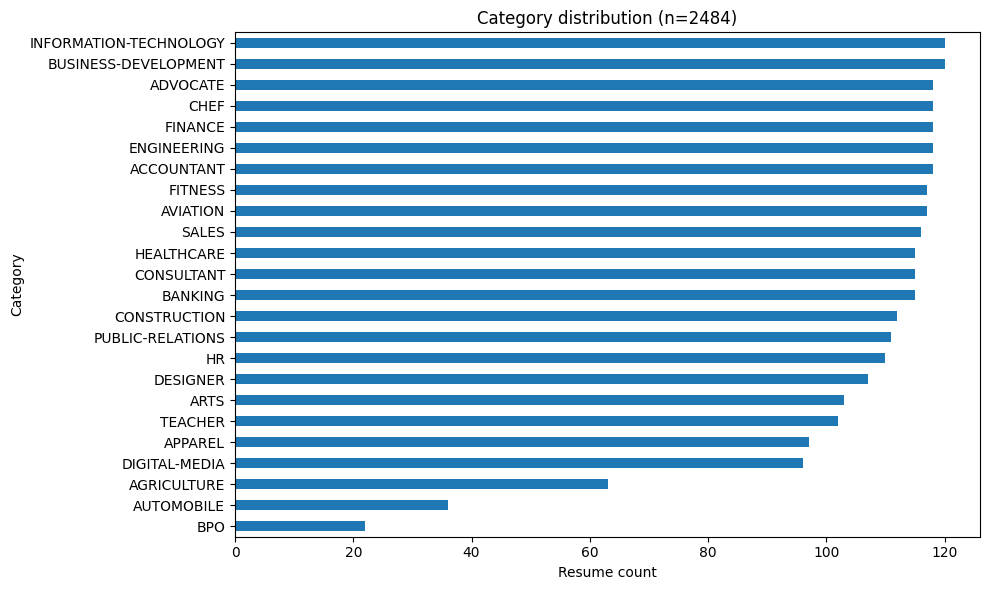

In [20]:
cat_counts = df['Category'].value_counts()
print(f'Unique categories: {len(cat_counts)}')
print(cat_counts)

fig, ax = plt.subplots(figsize=(10, 6))
cat_counts.plot.barh(ax=ax)
ax.set_xlabel('Resume count')
ax.set_title('Category distribution (n={})'.format(len(df)))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Keputusan — Filter kategori sidebar (Sesi 2)

Distribusi: 24 kategori, max=120 (INFORMATION-TECHNOLOGY), min=22 (BPO), rasio 5.5× — tidak sangat timpang.

- **Urutan:** alfabetis (A-Z). Stabil antar sesi; recruiter membangun muscle memory.
- **Format label:** `"<CATEGORY> (<count>)"` (mis. `"BPO (22)"`). Menyetel ekspektasi sebelum filter.
- **Kecualikan kategori kecil:** tidak — pertahankan semua 24. BPO dengan 22 resume tetap menghasilkan ~260 chunk, cukup untuk retrieval. Dibawa ke README sebagai limitation yang diketahui: kategori kecil bisa mengembalikan lebih sedikit hasil.

Implementasi ada di komponen sidebar Streamlit; count dihitung sekali dari `df['Category'].value_counts()` saat aplikasi start.

## Sesi 3 — Panjang `Resume_str`

**Pertanyaan:** panjang karakter mean, median, p95.

**Implikasi untuk `CHUNK_SIZE_FALLBACK = 500` karakter:**
- Median ~3000 karakter → resume rata-rata terpecah jadi ~6 fallback chunk. Wajar.
- p95 >> 10000 → beberapa resume akan menghasilkan puluhan chunk masing-masing; pertimbangkan cap atau strategi berbeda.

Resume_str length stats (chars):
count     2484.0
mean      6295.3
std       2769.3
min         21.0
5%        2436.2
25%       5160.0
50%       5886.5
75%       7227.2
95%      10792.6
99%      15913.9
max      38842.0
Name: len_chars, dtype: float64


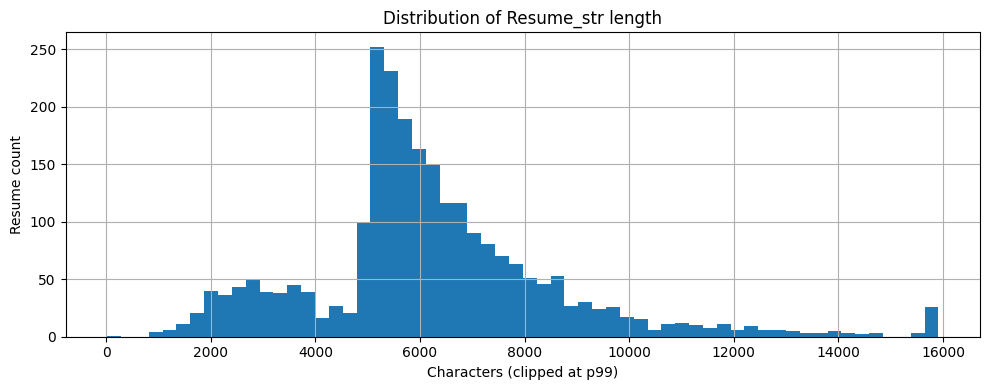

In [21]:
df['len_chars'] = df['Resume_str'].fillna('').str.len()
stats = df['len_chars'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print('Resume_str length stats (chars):')
print(stats.round(1))

fig, ax = plt.subplots(figsize=(10, 4))
df['len_chars'].clip(upper=df['len_chars'].quantile(0.99)).hist(bins=60, ax=ax)
ax.set_xlabel('Characters (clipped at p99)')
ax.set_ylabel('Resume count')
ax.set_title('Distribution of Resume_str length')
plt.tight_layout()
plt.show()

### Tindak lanjut — Resume yang mencurigakan pendek

Sesi 3 memunculkan `min = 21 karakter`, terlalu pendek untuk resume nyata. Sebelum mengunci parameter chunking, hitung berapa banyak baris pendek yang ada — mungkin perlu difilter.

**Aturan keputusan:**

| Jumlah resume < 500 karakter | Tindakan |
|---|---|
| 0–3 | Drop (kemungkinan artefak scrape) |
| 4–20 | Inspeksi dulu, lalu drop |
| > 20 | Berhenti — masalah sistemik yang perlu dipahami |

In [22]:
short_threshold = 500
short_mask = df['len_chars'] < short_threshold
print(f'Resumes shorter than {short_threshold} chars: {short_mask.sum()} '
      f'({short_mask.mean() * 100:.2f}% of corpus)\n')

if short_mask.any():
    short_rows = df.loc[short_mask, ['ID', 'Category', 'len_chars', 'Resume_str']]
    print('Short rows (sorted by length):')
    print(short_rows.sort_values('len_chars')[['ID', 'Category', 'len_chars']].to_string(index=False))

    print('\n--- Content of each short row ---')
    for _, row in short_rows.sort_values('len_chars').iterrows():
        print(f'\nID {row["ID"]} | {row["Category"]} | {row["len_chars"]} chars')
        print(f'  "{row["Resume_str"]}"')

Resumes shorter than 500 chars: 1 (0.04% of corpus)

Short rows (sorted by length):
      ID             Category  len_chars
12632728 BUSINESS-DEVELOPMENT         21

--- Content of each short row ---

ID 12632728 | BUSINESS-DEVELOPMENT | 21 chars
  "                     "


### Keputusan — Chunking + filter panjang (Sesi 3)

Distribusi panjang: median 5887, mean 6295, p95 10792, max 38842, min 21 karakter.

- **`CHUNK_SIZE_FALLBACK = 500`:** pertahankan apa adanya. Resume median → ~12 fallback chunk (granular tapi tidak berlebihan); p95 → ~22 chunk; p99 → ~32 chunk. Distribusi sehat.
- **Drop resume lebih pendek dari 500 karakter:** 1 baris ditemukan (ID 12632728, BUSINESS-DEVELOPMENT, 21 karakter, konten praktis kosong). Filter berdasarkan panjang alih-alih hard-code ID, agar aturan bertahan terhadap perubahan dataset.
- **Tanpa cap chunk maksimum:** outlier 38842 karakter akan menghasilkan 78 fallback chunk jika deteksi section gagal, tapi (a) deteksi section berhasil untuk 98.6% resume, (b) 78 embedding berbiaya ~USD 0.001 — dapat diabaikan.

**Korpus kumulatif setelah pipeline cleaning:**

| Langkah | Baris dipertahankan |
|---|---|
| Mentah | 2484 |
| − drop html-dup (Sesi 1b) | 2482 |
| − drop panjang < 500 karakter (Sesi 3) | **2481** |

**Urutan implementasi di `02_ingestion.ipynb`:**

```python
df = df.drop_duplicates(subset='Resume_html', keep='first')   # Session 1b
df = df.loc[df['Resume_str'].fillna('').str.len() >= 500]     # Session 3
df['Resume_clean'] = df['Resume_str'].map(clean_resume)       # Session 9
# ... then chunking
```

## Sesi 4 — Apakah `Resume_html` bocor ke `Resume_str`?

**Pertanyaan:** sebelumnya `cut -d',' -f4` yang naif menarik token mirip-CSS (`padding-top:0px`, `font-size: 12pt`). Itu bisa jadi artefak parsing CSV multiline, tapi bisa juga berarti `Resume_str` sendiri mengandung residu HTML.

**Implikasi:** bersihkan jika perlu (BeautifulSoup atau regex strip) sebelum chunking; jika tidak, embed langsung.

In [23]:
html_signals = {
    'tag <': df['Resume_str'].str.contains(r'<[a-zA-Z][^>]{0,40}>', regex=True, na=False),
    'css padding': df['Resume_str'].str.contains(r'padding\s*:', regex=True, na=False),
    'style attr':  df['Resume_str'].str.contains(r"style\s*=\s*['\"]", regex=True, na=False),
    '&entity;':    df['Resume_str'].str.contains(r'&[a-z]{2,6};', regex=True, na=False),
}
for name, mask in html_signals.items():
    pct = mask.mean() * 100
    print(f'  {name:14s} : {mask.sum():>5} resumes ({pct:5.1f}%)')

sample = df.loc[html_signals['tag <']].head(1)
if len(sample):
    print('\n--- Sample with HTML tag (first 200 chars) ---')
    print(repr(sample.iloc[0]['Resume_str'][:200]))

  tag <          :     0 resumes (  0.0%)
  css padding    :     0 resumes (  0.0%)
  style attr     :     0 resumes (  0.0%)
  &entity;       :     4 resumes (  0.2%)


## Sesi 5 — Tingkat deteksi header section

**Sesi paling berpengaruh** — outputnya menentukan strategi chunking.

**Pertanyaan:** untuk tiap section yang diharapkan (Summary, Skills, Experience, Education, Certifications), berapa persen resume yang punya header terdeteksi?

**Threshold keputusan:**
- ≥70% per section → hybrid section-aware + fallback fixed-size adalah pilihan tepat
- 40–70% → hybrid tetap OK tapi jalur fallback akan sering aktif
- <40% → buang kompleksitas deteksi section, pakai chunking fixed-size murni

In [24]:
# Coarse regex set; Session 6 refines exact patterns.
section_patterns = {
    'summary':        r'(?im)^\s*(summary|professional\s+summary|profile|objective|career\s+objective)\s*$',
    'skills':         r'(?im)^\s*(skills|skill\s+highlights|technical\s+skills|core\s+competencies|key\s+skills)\s*$',
    'experience':     r'(?im)^\s*(experience|work\s+experience|work\s+history|professional\s+experience|employment\s+history)\s*$',
    'education':      r'(?im)^\s*(education|education\s+and\s+training|academic\s+background)\s*$',
    'certifications': r'(?im)^\s*(certifications|certificates|licenses\s+and\s+certifications|professional\s+certifications)\s*$',
}

detection = pd.DataFrame({
    name: df['Resume_str'].fillna('').str.contains(pattern, regex=True)
    for name, pattern in section_patterns.items()
})

summary = pd.DataFrame({
    'detected': detection.sum(),
    'pct': (detection.mean() * 100).round(1),
})
print('Section detection rate:')
print(summary)

n_sections_per_resume = detection.sum(axis=1)
print('\nDistribution of sections detected per resume:')
print(n_sections_per_resume.value_counts().sort_index())
print('\n% with ≥3 sections detected: {:.1f}%'.format((n_sections_per_resume >= 3).mean() * 100))
print('% with 0 sections detected : {:.1f}%'.format((n_sections_per_resume == 0).mean() * 100))

/tmp/ipykernel_10063/3575380790.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  name: df['Resume_str'].fillna('').str.contains(pattern, regex=True)


Section detection rate:
                detected  pct
summary                4  0.2
skills                 3  0.1
experience             1  0.0
education              0  0.0
certifications         1  0.0

Distribution of sections detected per resume:
0    2475
1       9
Name: count, dtype: int64

% with ≥3 sections detected: 0.0%
% with 0 sections detected : 99.6%


## Sesi 6 — Varian pola header inline

**Update berdasarkan Sesi 5:** rencana awal adalah mencari header sebagai baris uppercase yang berdiri sendiri. Sesi 5 membantah premis itu — hanya ~0% resume yang punya header line-anchored. Kita beralih ke **deteksi inline**.

**Metode revisi:**

1. Pecah tiap `Resume_str` dengan deretan 3+ spasi (pembatas yang sudah kita verifikasi sebelumnya).
2. Filter potongan hasilnya ke yang *terlihat seperti* header: 2–30 karakter, diawali huruf kapital, tanpa tanda baca kalimat, bukan murni angka.
3. Hitung frekuensi di seluruh 2484 resume. Header section sejati (mis. `Skills`) akan berulang ribuan kali; label sekali-pakai (satu nama perusahaan) muncul sekali dan berada di paling bawah.

**Output ini memberi makan:** set regex inline Sesi 10 (nama section persis mana yang kita deteksi di produksi). Tidak ada keputusan diambil di sini; kita hanya mengumpulkan kosakata.

In [25]:
# 1. Split each Resume_str by runs of 3+ spaces.
all_pieces = []
for text in df['Resume_str'].fillna(''):
    pieces = re.split(r'\s{3,}', text)
    all_pieces.extend(p.strip() for p in pieces if p.strip())

print(f'Total pieces extracted (after splitting by 3+ spaces): {len(all_pieces):,}')
print(f'Average pieces per resume: {len(all_pieces) / len(df):.1f}')

# 2. Filter: looks like a header — short, capitalized, no sentence punctuation.
def looks_like_header(s):
    if not (2 <= len(s) <= 30):
        return False
    if not s[0].isupper():
        return False
    if any(c in s for c in '.,;:!?'):
        return False
    if s.replace(' ', '').isdigit():
        return False
    return True

header_candidates = [p for p in all_pieces if looks_like_header(p)]
print(f'Pieces that look like a header: {len(header_candidates):,}')

# 3. Frequency count — true section headers will be at the top.
print('\nTop 40 header candidates across all 2484 resumes:')
for header, count in Counter(header_candidates).most_common(40):
    pct_resumes = count / len(df) * 100
    print(f'  {count:>5}x  ({pct_resumes:>5.1f}% of resumes)  {header}')

Total pieces extracted (after splitting by 3+ spaces): 181,560
Average pieces per resume: 73.1
Pieces that look like a header: 74,215

Top 40 header candidates across all 2484 resumes:
  12984x  (522.7% of resumes)  State
  11488x  (462.5% of resumes)  Company Name
   2715x  (109.3% of resumes)  Skills
   1947x  ( 78.4% of resumes)  Education
   1866x  ( 75.1% of resumes)  Current
   1728x  ( 69.6% of resumes)  Experience
   1344x  ( 54.1% of resumes)  Summary
    876x  ( 35.3% of resumes)  Highlights
    766x  ( 30.8% of resumes)  Accomplishments
    537x  ( 21.6% of resumes)  USA
    508x  ( 20.5% of resumes)  Education and Training
    468x  ( 18.8% of resumes)  City
    462x  ( 18.6% of resumes)  Additional Information
    461x  ( 18.6% of resumes)  Professional Summary
    401x  ( 16.1% of resumes)  Professional Experience
    351x  ( 14.1% of resumes)  Work History
    284x  ( 11.4% of resumes)  Certifications
    280x  ( 11.3% of resumes)  US
    242x  (  9.7% of resumes)  High 

## Sesi 7 — Estimasi biaya token & embedding

**Pertanyaan:** total token jika seluruh korpus di-embed dengan `text-embedding-3-small`. Berapa proyeksi biaya USD-nya?

**Snapshot harga OpenAI:**
- `text-embedding-3-small`: USD 0.02 per 1 juta token
- `gpt-4o-mini` (untuk summary yang di-generate LLM): USD 0.15 input / 0.60 output per 1 juta token

In [26]:
import tiktoken

enc = tiktoken.encoding_for_model('text-embedding-3-small')

sample = df['Resume_str'].fillna('').sample(min(200, len(df)), random_state=42)
sample_tokens = sample.map(lambda t: len(enc.encode(t)))
mean_tokens_per_resume = sample_tokens.mean()
total_tokens_est = mean_tokens_per_resume * len(df)

print(f'Sample size              : {len(sample)}')
print(f'Mean tokens / resume     : {mean_tokens_per_resume:,.0f}')
print(f'Median tokens / resume   : {sample_tokens.median():,.0f}')
print(f'Total tokens (estimate)  : {total_tokens_est:,.0f}')
print()
embed_cost = total_tokens_est / 1_000_000 * 0.02
print(f'Embedding cost (chunks + summary input ~ 2x): USD {embed_cost * 2:.3f}')

# LLM-generated summary: assume full resume input, ~50 tokens output per resume.
llm_input_cost  = total_tokens_est / 1_000_000 * 0.15
llm_output_cost = (50 * len(df)) / 1_000_000 * 0.60
print(f'LLM summary input cost   : USD {llm_input_cost:.3f}')
print(f'LLM summary output cost  : USD {llm_output_cost:.3f}')
print(f'\nTOTAL estimated ingestion cost: USD {embed_cost*2 + llm_input_cost + llm_output_cost:.3f}')

Sample size              : 200
Mean tokens / resume     : 1,264
Median tokens / resume   : 1,176
Total tokens (estimate)  : 3,138,658

Embedding cost (chunks + summary input ~ 2x): USD 0.126
LLM summary input cost   : USD 0.471
LLM summary output cost  : USD 0.075

TOTAL estimated ingestion cost: USD 0.671


## Sesi 8 — Inspeksi sampel

**Pertanyaan:** inspeksi 3 resume mentah dari kategori berbeda. Hal yang dicari:
- Konsistensi format
- Overlap yang tampak antara `Resume_str` dan `Resume_html`
- Karakter tak biasa (newline berlebih, artefak encoding, tab)

In [27]:
# Categories in the raw CSV are UPPERCASE (e.g. INFORMATION-TECHNOLOGY).
for cat in ['INFORMATION-TECHNOLOGY', 'HR', 'HEALTHCARE']:
    sample_row = df[df['Category'] == cat].sample(1, random_state=7).iloc[0]
    print('=' * 80)
    print(f'Category : {cat}  | ID: {sample_row["ID"]}  | len: {len(sample_row["Resume_str"])}')
    print('=' * 80)
    print(sample_row['Resume_str'][:1500])
    print('...\n')

Category : INFORMATION-TECHNOLOGY  | ID: 15802627  | len: 8342
         SENIOR VICE-PRESIDENT AND CHIEF INFORMATION OFFICER             Core Accomplishments    Strategized with various areas of business to develop a proof of concept with an international financial company headed by a world-renowned Nobel Peace Prize winner to establish the principle of micro-lending for low income, immigrant families      Professional Experience      Senior Vice-President and Chief Information Officer  ,   01/2009   to   Current    Company Name   －   City  ,   State      Industry expert in a wide variety of technology systems, business applications and IT service management. Primary focus: Network Security and IT Operational Management using the fundamentals of scalar design/architecture and business process improvement. Create "living" technology that supports strategic vision and goals, as well as growing customer needs.  Instituted a technology roadmap to guide the IT department with proper business

## Sesi 9 — Langkah cleaning

**Tujuan:** mendefinisikan fungsi deterministik `clean_resume(text)` yang kita terapkan sebelum chunking, agar setiap langkah hilir bekerja pada bentuk ternormalisasi yang sama.

**Apa yang sesi-sesi sebelumnya beri tahu:**
- 0% tag HTML, 0% CSS inline → tidak perlu BeautifulSoup.
- 0.2% entity HTML (`&amp;` dll) → murah untuk di-decode demi kebenaran.
- `Resume_str` pada dasarnya teks polos dengan satu properti aneh…

**Bagian rumitnya — multi-spasi adalah fitur, bukan bug.**

Di Sesi 5 kita melihat header section (`Skills`, `Experience`, …) muncul *inline* di tengah baris panjang, dipisahkan dari teks sekitarnya oleh deretan 3+ spasi. Itu satu-satunya sinyal struktural yang kita punya. Cleaner naif seperti `re.sub(r'\\s+', ' ', text)` akan meratakan deretan itu dan **menghancurkan pembatas section kita**.

**Aturan cleaning yang diadopsi:**

| Tindakan | Alasan |
|---|---|
| `html.unescape` | Decode 0.2% `&amp;` / `&lt;` menjadi karakter literal |
| Normalisasi Unicode NFKC | Kanonikalisasi codepoint kompatibilitas (mis. fullwidth → ASCII) |
| Ganti `\\xa0`, `\\u2028`, `\\u2029`, `\\t` dengan spasi biasa | Menormalkan artefak ekstraksi PDF/HTML tanpa menggabungkan deretan |
| `.strip()` whitespace awal/akhir | Higiene sepele |
| **TIDAK** meratakan deretan spasi internal | Mempertahankan pembatas section `\\s{3,}` |
| **TIDAK** lowercase | Mempertahankan sinyal header UPPERCASE/Title Case |
| **TIDAK** rstrip newline secara agresif | Mayoritas resume sudah satu baris; collapsing jadi no-op |

Fungsi ini sengaja dibuat minimal — tiap baris membuktikan keberadaannya terhadap temuan di atas. Ia ada di notebook ini karena cleaning hanya berjalan saat ingestion — aplikasi live membaca data yang sudah dibersihkan dari Qdrant dan tidak membutuhkan fungsi ini.

In [28]:
import html
import unicodedata

EXOTIC_WHITESPACE = re.compile(r'[\xa0\u2028\u2029\t]')

def clean_resume(text: str) -> str:
    """Normalize a Resume_str cell without destroying inline section signals."""
    if not isinstance(text, str):
        return ''
    text = html.unescape(text)                   # &amp; -> & etc.
    text = unicodedata.normalize('NFKC', text)   # canonicalize unicode forms
    text = EXOTIC_WHITESPACE.sub(' ', text)      # tabs / nbsp / line+para sep -> space
    return text.strip()

# Apply to the whole frame.
df['Resume_clean'] = df['Resume_str'].fillna('').map(clean_resume)

# Sanity 1: length should be ~unchanged — cleaning is non-destructive on content.
delta = df['Resume_str'].fillna('').str.len() - df['Resume_clean'].str.len()
print('Char-count delta after cleaning (original - clean):')
print(delta.describe(percentiles=[0.5, 0.95, 0.99]).round(1).to_string())

# Sanity 2: the section delimiter signal must survive.
multi_space = df['Resume_clean'].str.count(r' {3,}')
print('\nRuns of 3+ spaces per resume AFTER cleaning:')
print(multi_space.describe(percentiles=[0.5, 0.95]).round(1).to_string())
print(f"\nresumes with zero multi-space runs: {(multi_space == 0).sum()} "
      f"({(multi_space == 0).mean() * 100:.1f}%)")
print('(Should be near zero — otherwise our section detection breaks.)')

# Spot check: a resume that originally had HTML entities, before vs after.
had_entities = df['Resume_str'].fillna('').str.contains(r'&[a-z]{2,6};', regex=True, na=False)
if had_entities.any():
    row = df.loc[had_entities].iloc[0]
    m = re.search(r'&[a-z]{2,6};', row['Resume_str'])
    if m:
        s, e = max(0, m.start() - 30), min(len(row['Resume_str']), m.end() + 30)
        print('\n--- Entity decode spot check ---')
        print(f'original: ...{row["Resume_str"][s:e]}...')
        print(f'cleaned : ...{row["Resume_clean"][s:e]}...')

Char-count delta after cleaning (original - clean):
count    2484.0
mean       13.7
std         3.2
min       -42.0
50%        13.0
95%        18.0
99%        24.0
max        64.0

Runs of 3+ spaces per resume AFTER cleaning:
count    2484.0
mean       72.1
std        30.6
min         0.0
50%        67.0
95%       120.0
max       758.0

resumes with zero multi-space runs: 1 (0.0%)
(Should be near zero — otherwise our section detection breaks.)

--- Entity decode spot check ---
original: ...owledge of osteoporosis, women&apos;s health, men&apos;s health an...
cleaned : ...f osteoporosis, women's health, men's health and musculoskeletal p...


## Sesi 10 — Deteksi section inline (taksonomi kanonik)

**Sesi kanonik untuk chunker.** Terapkan regex inline `\\s{3,}(<header>)\\s{3,}` ke kolom yang **sudah dibersihkan**, dengan synonym map yang menggabungkan varian ("Professional Experience", "Work History" → `experience`) menjadi set kecil section kanonik.

**Kenapa ini penting:** Sesi 6 memunculkan kosakata mentah; di sini kita ambil keputusan operasional — section kanonik mana yang kita lacak di produksi, dan berapa tingkat deteksi masing-masing pada korpus yang sudah dibersihkan?

**Synonym map (draft — berdasarkan Sesi 6 + 8):**

```python
{
    'summary'                : ['Summary', 'Professional Summary', 'Career Overview', 'Profile', 'Objective'],
    'skills'                 : ['Skills', 'Core Qualifications', 'Skill Highlights', 'Technical Skills', 'Core Competencies', 'Key Skills'],
    'experience'             : ['Experience', 'Professional Experience', 'Work History', 'Work Experience', 'Employment History'],
    'education'              : ['Education', 'Education and Training', 'Academic Background'],
    'highlights'             : ['Highlights', 'Career Highlights'],
    'accomplishments'        : ['Accomplishments', 'Core Accomplishments', 'Achievements'],
    'certifications'         : ['Certifications', 'Certificates', 'Professional Certifications', 'Licenses'],
    'additional_information' : ['Additional Information'],
    'languages'              : ['Languages'],
}
```

**Keputusan didorong oleh output:**

| Tingkat deteksi kanonik | Tindakan di Sesi 11 (penguncian taksonomi) |
|---|---|
| ≥ 70 % | Sertakan dalam taksonomi produksi |
| 30 – 70 % | Sertakan tapi terima cakupan lebih rendah |
| < 30 % | Drop (perlakukan konten sebagai body) atau pertahankan sebagai opsional |

In [33]:
SYNONYM_MAP = {
    'summary'                : ['Summary', 'Professional Summary', 'Career Overview', 'Professional Overview', 'Profile', 'Objective'],
    'skills'                 : ['Skills', 'Core Qualifications', 'Skill Highlights', 'Technical Skills', 'Core Competencies', 'Key Skills'],
    'experience'             : ['Experience', 'Professional Experience', 'Work History', 'Work Experience', 'Employment History'],
    'education'              : ['Education', 'Education and Training', 'Academic Background'],
    'highlights'             : ['Highlights', 'Career Highlights'],
    'accomplishments'        : ['Accomplishments', 'Core Accomplishments', 'Achievements'],
    'certifications'         : ['Certifications', 'Certificates', 'Professional Certifications', 'Licenses'],
    'additional_information' : ['Additional Information'],
    'languages'              : ['Languages'],
}

# Build one regex per canonical, matching any synonym between \s{3,} runs.
def build_pattern(synonyms):
    escaped = [re.escape(s) for s in synonyms]
    return re.compile(r'\s{3,}(' + '|'.join(escaped) + r')\s{3,}', re.IGNORECASE)

patterns = {canonical: build_pattern(syns) for canonical, syns in SYNONYM_MAP.items()}

# Apply to the cleaned column.
detection = pd.DataFrame({
    canonical: df['Resume_clean'].str.contains(pat, regex=True)
    for canonical, pat in patterns.items()
})

# Detection rate per canonical section.
summary_df = pd.DataFrame({
    'detected_resumes': detection.sum(),
    'pct_of_corpus'   : (detection.mean() * 100).round(1),
}).sort_values('pct_of_corpus', ascending=False)

print('Canonical section detection rate (on Resume_clean):')
print(summary_df.to_string())

# Distribution of sections detected per resume.
n_sections = detection.sum(axis=1)
print('\nDistribution of canonical sections detected per resume:')
print(n_sections.value_counts().sort_index().to_string())
print(f'\n% with ≥ 3 canonical sections detected: {(n_sections >= 3).mean() * 100:.1f}%')
print(f'% with ≥ 4 canonical sections detected: {(n_sections >= 4).mean() * 100:.1f}%')
print(f'% with 0 canonical sections detected  : {(n_sections == 0).mean() * 100:.1f}%')

/tmp/ipykernel_10063/699260736.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  canonical: df['Resume_clean'].str.contains(pat, regex=True)


Canonical section detection rate (on Resume_clean):
                        detected_resumes  pct_of_corpus
experience                          2468           99.4
education                           2419           97.4
skills                              2379           95.8
summary                             1966           79.1
accomplishments                      876           35.3
highlights                           874           35.2
additional_information               458           18.4
certifications                       307           12.4
languages                            240            9.7

Distribution of canonical sections detected per resume:
0      1
1      2
2     20
3    229
4    787
5    750
6    530
7    142
8     21
9      2

% with ≥ 3 canonical sections detected: 99.1%
% with ≥ 4 canonical sections detected: 89.9%
% with 0 canonical sections detected  : 0.0%


### Tindak lanjut — Inspeksi resume tanpa section

99.9% korpus punya ≥1 section kanonik terdeteksi. 2 resume tersisa entah (a) korup/kosong, atau (b) memakai nama section non-standar yang synonym map kita lewatkan. Layak dilihat sekilas — jika (b), kita mungkin perlu memperluas synonym map sebelum mengunci taksonomi di Sesi 11.

In [34]:
zero_mask = (detection.sum(axis=1) == 0)
zero_rows = df.loc[zero_mask, ['ID', 'Category', 'Resume_clean']].copy()
zero_rows['len'] = zero_rows['Resume_clean'].str.len()

print(f'Zero-section resumes: {zero_mask.sum()}\n')
for _, row in zero_rows.iterrows():
    print('=' * 70)
    print(f'ID {row["ID"]} | {row["Category"]} | {row["len"]} chars')
    print('=' * 70)
    print(row['Resume_clean'][:700])
    print('...' if row['len'] > 700 else '')
    print()

Zero-section resumes: 1

ID 12632728 | BUSINESS-DEVELOPMENT | 0 chars





## Sesi 11 — Penguncian: taksonomi, threshold, format page_content

Tiga keputusan operasional, dikunci setelah validasi empiris di Sesi 9–10.

---

### 1. Taksonomi section kanonik — sertakan semua 9

```python
SYNONYM_MAP = {
    'summary'                : ['Summary', 'Professional Summary', 'Career Overview', 'Professional Overview', 'Profile', 'Objective'],
    'skills'                 : ['Skills', 'Core Qualifications', 'Skill Highlights', 'Technical Skills', 'Core Competencies', 'Key Skills'],
    'experience'             : ['Experience', 'Professional Experience', 'Work History', 'Work Experience', 'Employment History'],
    'education'              : ['Education', 'Education and Training', 'Academic Background'],
    'highlights'             : ['Highlights', 'Career Highlights'],
    'accomplishments'        : ['Accomplishments', 'Core Accomplishments', 'Achievements'],
    'certifications'         : ['Certifications', 'Certificates', 'Professional Certifications', 'Licenses'],
    'additional_information' : ['Additional Information'],
    'languages'              : ['Languages'],
}
```

**Kenapa semua 9 (termasuk yang langka):**

- **Batas chunk lebih bersih.** Melacak `Languages` sebagai section berarti kontennya mendapat chunk sendiri dengan provenance yang benar. Tidak melacaknya akan mencampur konten Languages ke chunk section sebelumnya.
- **Soft metadata untuk display.** UI bisa menampilkan "kutipan dari section Languages kandidat" — UX recruiter lebih baik.

**Kenapa ini BUKAN untuk filtering.** Lihat aturan metadata di bawah.

---

### 2. Threshold chunker hybrid — ≥3 section terdeteksi → section-aware; selain itu fallback

| Resume kena fallback (window fixed-size 500 karakter) | ~1% |
|---|---|
| Resume pakai batas section-aware | ~99% |

Threshold ≥3 dipilih karena resume dengan hanya 1–2 section terdeteksi kemungkinan punya satu section yang sangat besar (biasanya satu blok `experience`) — windowing 500 karakter seragam menghasilkan chunk yang lebih konsisten untuk kasus tepi itu dibanding split section naif.

---

### 3. Format `page_content` — Minimalis

```python
# Per chunk:
page_content = "<raw cleaned text of the chunk>"
metadata = {
    "resume_id"  : "12345678",
    "category"   : "INFORMATION-TECHNOLOGY",   # hard filter
    "section"    : "experience",               # SOFT metadata only
    "chunk_index": 3,
}
```

**Kenapa minimalis (bukan enrichment prefix-section):**

- Embedding adalah konten murni — tanpa bias ke section yang "benar".
- Reranker cross-encoder menangani nuansa section/konten saat re-ranking.
- Display lebih bersih di UI (tanpa artefak `[section]` ter-bake ke teks snippet).
- Portabel: jika kita ganti model embedding nanti, konten tetap kanonik.

**Contoh konkret bias yang kita hindari.** Query: *"AWS skills"*. Sebuah chunk dari `experience` berisi "Led AWS migration to multi-region EKS" lebih berguna daripada chunk `skills` yang jarang "AWS, Docker, Kubernetes". Enrichment prefix-section akan meranking chunk `skills` keyword-telanjang lebih tinggi hanya karena label section cocok dengan kata query — sebuah kerugian kualitas konten.

---

### Aturan arsitektural kritikal

> **`section` adalah soft metadata saja — TIDAK PERNAH dipakai sebagai hard filter di query Qdrant. Satu-satunya hard filter yang user-facing adalah `category`.**

Kenapa: nama-section-sebagai-filter menciptakan false negative. Query seperti "kandidat AWS certified" yang difilter ke `section == 'certifications'` akan melewatkan kandidat yang menulis sertifikasi AWS-nya di `experience`. Pencarian semantik lintas semua section menangani penemuan konten-keyword; filter metadata dicadangkan untuk atribut ortogonal universal (setiap resume punya tepat satu `category`).

Aturan ini berlaku ke depan untuk:
- Query layer retrieval: filter `must` hanya memuat `category`, tidak pernah `section`
- UI sidebar: hanya mengekspos category sebagai chip filter; section muncul sebagai label display di hasil
- Jika fitur masa depan memunculkan "cari hanya di section Skills", itu fitur query-rewriting (tulis ulang query agar fokus-skill via LLM), BUKAN filter metadata

---

### Antrean implementasi untuk `02_ingestion.ipynb`

```python
# 1. Clean pipeline
df = df.drop_duplicates(subset='Resume_html', keep='first')
df = df.loc[df['Resume_str'].fillna('').str.len() >= 500]
df['Resume_clean'] = df['Resume_str'].map(clean_resume)

# 2. Chunk pipeline (per resume):
#    a. Detect canonical sections via SYNONYM_MAP regex
#    b. If ≥3 sections detected → split at section boundaries → sub-split long sections to 500-char window
#    c. Else → uniform 500-char window (fallback)
#    d. Each chunk gets metadata: {resume_id, category, section, chunk_index}

# 3. Embed each chunk → upsert to Qdrant resume_chunks collection
# 4. Generate per-resume summary via LLM → embed → upsert to resume_summaries collection
```

## Sesi 12 — Prototipe chunker + validasi

Implementasikan chunker hybrid yang kita kunci di Sesi 11, lalu terapkan ke 5 sampel resume yang beragam untuk memverifikasi batas chunk, atribusi section, dan distribusi panjang.

**Ringkasan algoritma:**

1. Temukan semua posisi header section via regex `SYNONYM_MAP` (case-insensitive; sinonim lebih panjang dicoba lebih dulu via sort panjang-desc, jadi `Education and Training` cocok sebelum `Education`).
2. Jika ≥ 3 section *kanonik unik* terdeteksi → **jalur section-aware**:
   - Preamble (teks sebelum header pertama) → ditandai `title`.
   - Tiap section: konten mulai **setelah** kata header, berakhir di header berikutnya (atau akhir teks).
   - Section > 500 karakter → di-sub-split via sliding window (ukuran 500, overlap 50).
3. Selain itu → **jalur fallback**: sliding window atas seluruh teks, semua chunk ditandai `body`.
4. Kata header section dihapus dari konten chunk (demi konsistensi minimalis).

**Sampel validasi:**

| ID | Kategori | Kenapa sampel ini |
|---|---|---|
| 15802627 | INFORMATION-TECHNOLOGY | CV eksekutif (Sesi 8) — struktur standar |
| 72231872 | HR | CV generalis (Sesi 8) — panjang menengah tipikal |
| 36868767 | HEALTHCARE | CV admin (Sesi 8) — lebih pendek |
| 17111768 | INFORMATION-TECHNOLOGY | CV federal — kasus tepi "Professional Overview" |
| (acak) | BPO | Sanity check kategori tail kecil |

**Yang akan Anda inspeksi:**

- Chunk per section — tiap section terdeteksi harus muncul; jumlahnya wajar untuk ukuran konten.
- Distribusi panjang — mayoritas chunk ≤ 500 karakter; beberapa ekor lebih pendek di akhir section.
- Preview chunk-pertama-per-section — konten cocok dengan label section (tanpa bleed).

In [ ]:
def chunk_resume(resume_id, category, text, synonym_map,
                  chunk_size=500, overlap=50, min_sections=3):
    """Hybrid section-aware chunker with sliding-window sub-chunks."""

    # 1. Find all section markers. Longer synonyms tried first.
    markers = []
    for canonical, synonyms in synonym_map.items():
        syn_sorted = sorted(synonyms, key=len, reverse=True)
        pat = re.compile(
            r'\s{3,}(' + '|'.join(re.escape(s) for s in syn_sorted) + r')\s{3,}',
            re.IGNORECASE,
        )
        for m in pat.finditer(text):
            markers.append((m.start(1), m.end(1), canonical))

    markers.sort()

    # 1b. Collapse consecutive same-canonical markers (e.g. "Experience" right before
    # "Work History"): drop the redundant ones so the first marker's content spans
    # through to the next *different* canonical section.
    collapsed = []
    for m in markers:
        if collapsed and collapsed[-1][2] == m[2]:
            continue
        collapsed.append(m)
    markers = collapsed

    # 2. Decide path.
    unique_sections = {name for _, _, name in markers}
    if len(unique_sections) < min_sections:
        return _sliding(resume_id, category, 'body', text.strip(),
                        chunk_size, overlap, base_idx=0)

    # 3. Section-aware path.
    chunks = []

    # Preamble before first header → 'title'.
    if markers[0][0] > 0:
        preamble = text[:markers[0][0]].strip()
        if preamble:
            chunks.extend(_sliding(resume_id, category, 'title', preamble,
                                   chunk_size, overlap, base_idx=len(chunks)))

    # Each detected section.
    for i, (start, end, name) in enumerate(markers):
        content_start = end
        content_end = markers[i+1][0] if i+1 < len(markers) else len(text)
        content = text[content_start:content_end].strip()
        if content:
            chunks.extend(_sliding(resume_id, category, name, content,
                                   chunk_size, overlap, base_idx=len(chunks)))
    return chunks


def _sliding(resume_id, category, section, text,
             chunk_size, overlap, base_idx):
    """Sub-split text via sliding window. Stops when end is reached."""
    if not text:
        return []
    if len(text) <= chunk_size:
        return [{
            'resume_id': resume_id, 'category': category, 'section': section,
            'chunk_index': base_idx, 'content': text,
        }]
    chunks = []
    step = chunk_size - overlap
    pos = 0
    while pos < len(text):
        sub = text[pos:pos + chunk_size]
        chunks.append({
            'resume_id': resume_id, 'category': category, 'section': section,
            'chunk_index': base_idx + len(chunks), 'content': sub,
        })
        if pos + chunk_size >= len(text):
            break
        pos += step
    return chunks


# -------- Apply to 5 diverse samples --------
sample_ids = [15802627, 72231872, 36868767, 17111768]
bpo_id = int(df[df['Category'] == 'BPO'].sample(1, random_state=7).iloc[0]['ID'])
sample_ids.append(bpo_id)

for rid in sample_ids:
    row = df[df['ID'] == rid].iloc[0]
    chunks = chunk_resume(row['ID'], row['Category'],
                          row['Resume_clean'], SYNONYM_MAP)

    print('=' * 70)
    print(f'ID {rid} | {row["Category"]} | '
          f'{len(row["Resume_clean"])} chars → {len(chunks)} chunks')
    print('=' * 70)

    section_counts = Counter(c['section'] for c in chunks)
    print('Chunks per section:')
    for sec, n in section_counts.most_common():
        print(f'  {sec:25s} : {n}')

    lens = [len(c['content']) for c in chunks]
    print(f'Chunk length: min={min(lens)} | mean={sum(lens)/len(lens):.0f} | max={max(lens)}')

    print('First chunk per section (150-char preview):')
    seen = set()
    for c in chunks:
        if c['section'] in seen:
            continue
        seen.add(c['section'])
        preview = c['content'][:150].replace('\n', ' ')
        print(f'  [{c["section"]:22s}] "{preview}..."')
    print()

### Tindak lanjut — Seperti apa sebenarnya chunk di bawah 30 karakter?

Threshold untuk "filtering noise" dipilih sembarangan. Selesaikan secara empiris: generate chunk untuk seluruh korpus yang sudah dibersihkan, lalu baca yang mungil-mungil secara langsung.

In [37]:
# Apply the cleaning policies we decided earlier so chunk distribution reflects production.
df_clean = (df.drop_duplicates(subset='Resume_html', keep='first')
              .loc[lambda d: d['Resume_str'].fillna('').str.len() >= 500]
              .reset_index(drop=True))
print(f'Corpus after dedup + length filter: {len(df_clean)} resumes')

all_chunks = []
for _, row in df_clean.iterrows():
    all_chunks.extend(chunk_resume(row['ID'], row['Category'],
                                    row['Resume_clean'], SYNONYM_MAP))
print(f'Total chunks generated: {len(all_chunks):,}')

# Chunk length distribution.
chunk_lens = pd.Series([len(c['content']) for c in all_chunks])
print('\nChunk length stats:')
print(chunk_lens.describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99]).round(0).to_string())

# Inspect all chunks under 30 chars.
tiny = [c for c in all_chunks if len(c['content']) < 30]
print(f'\nChunks <30 chars: {len(tiny)} ({len(tiny)/len(all_chunks)*100:.3f}% of total)')

print('\nDistribution by section (tiny chunks):')
print(pd.Series([c['section'] for c in tiny]).value_counts().to_string())

print('\nSample tiny chunks (sorted shortest → longest, first 30 shown):')
for c in sorted(tiny, key=lambda c: len(c['content']))[:30]:
    L = len(c['content'])
    print(f'  [{L:>3} chars | {c["section"]:22s}] "{c["content"]}"')

Corpus after dedup + length filter: 2481 resumes
Total chunks generated: 41,813

Chunk length stats:
count    41813.0
mean       396.0
std        161.0
min          1.0
0.1%         5.0
1%          12.0
5%          35.0
50%        500.0
95%        500.0
99%        500.0
max        500.0

Chunks <30 chars: 1785 (4.269% of total)

Distribution by section (tiny chunks):
title                     1588
languages                   70
certifications              31
skills                      31
experience                  20
additional_information      15
education                   13
accomplishments             11
highlights                   4
summary                      2

Sample tiny chunks (sorted shortest → longest, first 30 shown):
  [  1 chars | additional_information] "2"
  [  1 chars | additional_information] "2"
  [  2 chars | skills                ] ";;"
  [  3 chars | certifications        ] "AIT"
  [  3 chars | certifications        ] "PTA"
  [  3 chars | certifications      

#### Inspeksi mikro — chunk `experience` mungil

Apakah 20 chunk `experience` kecil itu (a) bug sliding-window yang menghasilkan ekor aneh, atau (b) kuirk konten asli di resume-resume itu?

In [45]:
tiny_exp = [c for c in all_chunks if c['section'] == 'experience' and len(c['content']) < 30]
print(f'Tiny experience chunks: {len(tiny_exp)}\n')

for c in sorted(tiny_exp, key=lambda c: len(c['content'])):
    L = len(c['content'])
    print(f'  [resume_id={c["resume_id"]} | chunk_idx={c["chunk_index"]:>2} | {L:>2} chars] "{c["content"]}"')

# Also show context: how many chunks total did each of those resumes produce?
print('\nContext — total chunks per resume that produced a tiny experience chunk:')
rid_counts = {}
for c in all_chunks:
    rid_counts[c['resume_id']] = rid_counts.get(c['resume_id'], 0) + 1

seen_rids = set()
for c in sorted(tiny_exp, key=lambda c: len(c['content'])):
    if c['resume_id'] in seen_rids:
        continue
    seen_rids.add(c['resume_id'])
    print(f'  resume {c["resume_id"]}: {rid_counts[c["resume_id"]]} total chunks')

Tiny experience chunks: 16

  [resume_id=51769822 | chunk_idx=13 | 12 chars] "Company Name"
  [resume_id=22506245 | chunk_idx=10 | 12 chars] "Company Name"
  [resume_id=70892619 | chunk_idx= 1 | 12 chars] "Company Name"
  [resume_id=27798860 | chunk_idx=25 | 12 chars] "Company Name"
  [resume_id=20427934 | chunk_idx=13 | 12 chars] "Company Name"
  [resume_id=20141807 | chunk_idx=13 | 12 chars] "Company Name"
  [resume_id=24828381 | chunk_idx=16 | 12 chars] "Company Name"
  [resume_id=21568833 | chunk_idx=15 | 12 chars] "Company Name"
  [resume_id=34583750 | chunk_idx= 9 | 12 chars] "Company Name"
  [resume_id=23009962 | chunk_idx=12 | 12 chars] "Company Name"
  [resume_id=12071138 | chunk_idx=27 | 12 chars] "Company Name"
  [resume_id=12059610 | chunk_idx=16 | 12 chars] "Company Name"
  [resume_id=10985403 | chunk_idx=12 | 12 chars] "Company Name"
  [resume_id=98559931 | chunk_idx=16 | 12 chars] "Company Name"
  [resume_id=12695537 | chunk_idx=13 | 12 chars] "Company Name"
  [resume_id

#### Inspeksi mikro — chunk pendek di section kritikal-retrieval

Sebelum mengunci threshold filter, lihat apa yang sebenarnya dimuat *konten pendek* di skills, certifications, languages, accomplishments. Jika kita melihat keyword bermakna seperti "AWS" atau "PMP", threshold-nya perlu lebih rendah dari yang saya usulkan.

In [46]:
RETRIEVAL_SECTIONS = ['skills', 'certifications', 'languages',
                       'accomplishments', 'additional_information']

for sec in RETRIEVAL_SECTIONS:
    short_in_sec = [c for c in all_chunks
                    if c['section'] == sec and len(c['content']) < 15]
    print(f'\n=== {sec}: {len(short_in_sec)} chunks <15 chars ===')
    for c in sorted(short_in_sec, key=lambda c: len(c['content'])):
        L = len(c['content'])
        print(f'  [{L:>2} chars | resume_id={c["resume_id"]}] "{c["content"]}"')


=== skills: 16 chunks <15 chars ===
  [ 6 chars | resume_id=20001721] "Skills"
  [ 6 chars | resume_id=28897981] "Skills"
  [ 6 chars | resume_id=20748929] "Skills"
  [ 6 chars | resume_id=29134721] "Skills"
  [ 6 chars | resume_id=21366189] "Skills"
  [ 6 chars | resume_id=10549585] "Skills"
  [ 6 chars | resume_id=26829561] "Skills"
  [ 6 chars | resume_id=55595908] "Skills"
  [ 6 chars | resume_id=18457785] "Skills"
  [ 6 chars | resume_id=53227466] "Skills"
  [ 6 chars | resume_id=25718772] "Skills"
  [ 7 chars | resume_id=39434376] "Spanish"
  [ 8 chars | resume_id=25098739] "Painting"
  [11 chars | resume_id=20399718] "Proficienct"
  [12 chars | resume_id=39566718] "MSWord,Excel"
  [12 chars | resume_id=94230796] "Credit, Page"

=== certifications: 13 chunks <15 chars ===
  [ 3 chars | resume_id=29075857] "AIT"
  [ 3 chars | resume_id=28916894] "PTA"
  [ 3 chars | resume_id=95429627] "CPA"
  [ 3 chars | resume_id=28831378] "AIT"
  [ 3 chars | resume_id=19545827] "CPA"
  [ 3 char

### Keputusan — Kebijakan filter chunk (dikunci setelah inspeksi Sesi 12)

Setelah inspeksi empiris chunk pendek di section kritikal-retrieval, filter panjang `<15` awal ditolak — ia akan membuang konten yang sah (cert 3 karakter seperti CPA/PMP, bahasa "Spanish", dll).

**Kebijakan final — diterapkan di `02_ingestion.ipynb` antara generasi chunk dan upsert Qdrant:**

```python
CANONICAL_HEADER_WORDS = {
    'skills', 'experience', 'education', 'summary',
    'highlights', 'accomplishments', 'certifications',
    'additional information', 'languages',
    # plus common synonyms that may leak as content after marker collapse
    'professional summary', 'professional experience', 'work history',
    'core qualifications', 'skill highlights', 'core accomplishments',
    'career overview', 'professional overview',
}

PII_PLACEHOLDERS = {
    'Company Name', 'City', 'State', 'USA',
    'Total Years    Last Used',
}

def is_keepable(chunk):
    content = chunk['content'].strip()
    # 1. Title section: drop if too short (category restatement).
    if chunk['section'] == 'title' and len(content) < 20:
        return False
    # 2. Header word leaked as content (post-collapse artifact).
    if content.lower() in CANONICAL_HEADER_WORDS:
        return False
    # 3. Known PII placeholder.
    if content in PII_PLACEHOLDERS:
        return False
    # 4. Hard floor — 1-2 char content is noise (page numbers, residual punctuation).
    if len(content) < 3:
        return False
    return True
```

**Jumlah drop (estimasi dari run korpus penuh):**

| Aturan | Chunk dibuang |
|---|---|
| Title <20 karakter (restatement kategori) | ~1588 |
| Kata header bocor sebagai konten | ~11 |
| Cocok placeholder PII | ~17 |
| <3 karakter (nomor halaman dll.) | ~10 |
| **Total** | **~1626 (3.9% dari 41.813)** |

**Dipertahankan (yang akan salah dibuang oleh filter `<15`):**

- ✅ Kode sertifikasi 3 karakter: `CPA`, `PMP`, `AIT`, `PTA`, `OTR`, `CAA`
- ✅ Bahasa satu kata: `Spanish`, `English`, `Sign language`
- ✅ Daftar skill pendek: `MSWord,Excel`, `Painting`
- ✅ Konten satu-keyword masa depan seperti `AWS`, `PHP`, `SQL`

**Pelajaran engineering tercatat:** filter berbasis panjang perlu validasi empiris terhadap data nyata. Gut-threshold `<15` akan membuang kandidat yang hanya bersertifikat CPA dari retrieval. Pertanyaan "kalau cari AWS bisa jadi tidak ketemu?" menangkap cacat desain ini sebelum ter-ship.

---

## Temuan & dampak ke `config.py`

_Isi setelah menjalankan semua sesi. Pola yang perlu dicatat:_

1. **Strategi chunking** — keputusan final: hybrid / pure fixed-size / pure section-aware
2. **page_content vs metadata** — minimal, atau diperkaya dengan nama section?
3. **Generasi summary** — biaya LLM-generated terkonfirmasi dalam anggaran?
4. **`CHUNK_SIZE_FALLBACK`** — pertahankan 500 karakter atau sesuaikan?
5. **Langkah cleaning** — strip residu HTML dengan BeautifulSoup/regex, atau `Resume_str` sudah cukup bersih?
6. **Set regex header** — pola mana dari Sesi 6 yang masuk ke chunker?
7. **Estimasi biaya** — total ingestion dalam anggaran proyek?